# Phase 2: Exploratory Data Analysis (EDA)

This notebook explores the dataset structure, missingness, distributions, and initial hypotheses.

**Goals**:
- Understand feature types and ranges
- Inspect missing values
- Review target balance
- Identify potential feature engineering ideas

In [2]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from config.pipeline_config import DATASET_PATH, TARGET_COLUMN, NUMERIC_FEATURES, CATEGORICAL_FEATURES

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [3]:
# Load dataset
df = pd.read_csv(DATASET_PATH)
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [4]:
# Basic shape and dtypes
df.shape, df.dtypes

((840, 14),
 Weather                     str
 Road_Type                   str
 Time_of_Day                 str
 Traffic_Density         float64
 Speed_Limit             float64
 Number_of_Vehicles      float64
 Driver_Alcohol          float64
 Accident_Severity           str
 Road_Condition              str
 Vehicle_Type                str
 Driver_Age              float64
 Driver_Experience       float64
 Road_Light_Condition        str
 Accident                float64
 dtype: object)

In [5]:
# Missing values per column
missing = df.isna().sum().sort_values(ascending=False)
missing

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

In [6]:
# Target distribution
target_dist = df[TARGET_COLUMN].value_counts(normalize=True)
target_dist

Accident
0.0    0.700501
1.0    0.299499
Name: proportion, dtype: float64

In [7]:
# Numerical summary statistics
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
Traffic_Density,798.0,1.001253,0.784894,0.0,0.0,1.0,2.00,2.0
Speed_Limit,798.0,71.050125,32.052458,30.0,50.0,60.0,80.00,213.0
Number_of_Vehicles,798.0,3.286967,2.017267,1.0,2.0,3.0,4.00,14.0
Driver_Alcohol,798.0,0.160401,0.367208,0.0,0.0,0.0,0.00,1.0
Driver_Age,798.0,43.259398,15.129856,18.0,30.0,43.0,56.00,69.0
Driver_Experience,798.0,38.981203,15.273201,9.0,26.0,39.0,52.75,69.0


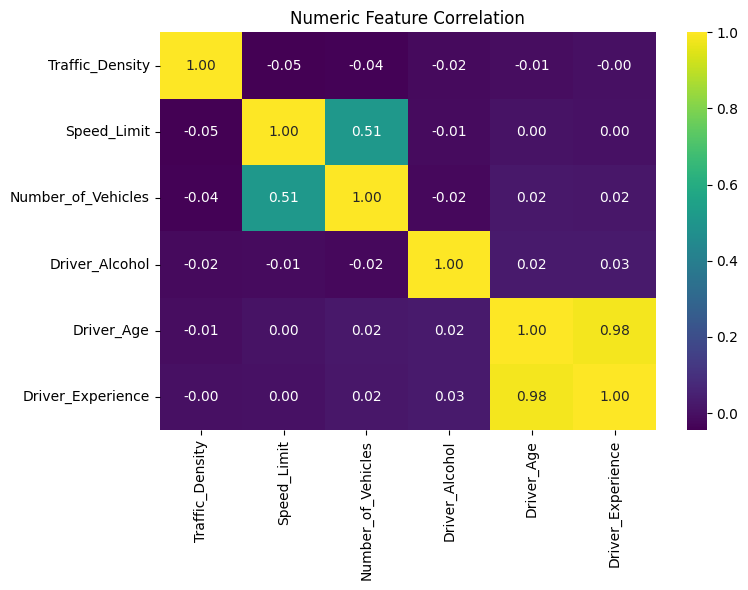

In [11]:
# Correlation heatmap for numeric features
plt.figure(figsize=(8, 6))
corr = df[NUMERIC_FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Numeric Feature Correlation")
plt.tight_layout()